# Experimentation
Compares baseline classifiers and regressors, runs cross-validation, and selects the best model for each task.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

DATA_DIR = '../Dataset/Processed/'
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')

## 1. Load Processed Data

In [2]:
X_train_clf = pd.read_csv(f'{DATA_DIR}X_train_clf.csv')
X_val_clf   = pd.read_csv(f'{DATA_DIR}X_val_clf.csv')
y_train_clf = pd.read_csv(f'{DATA_DIR}y_train_clf.csv').squeeze()
y_val_clf   = pd.read_csv(f'{DATA_DIR}y_val_clf.csv').squeeze()

X_train_reg = pd.read_csv(f'{DATA_DIR}X_train_reg.csv')
X_val_reg   = pd.read_csv(f'{DATA_DIR}X_val_reg.csv')
y_train_reg = pd.read_csv(f'{DATA_DIR}y_train_reg.csv').squeeze()
y_val_reg   = pd.read_csv(f'{DATA_DIR}y_val_reg.csv').squeeze()

print(f'Classification train: {X_train_clf.shape}, val: {X_val_clf.shape}')
print(f'Regression    train: {X_train_reg.shape}, val: {X_val_reg.shape}')

Classification train: (114794, 7), val: (13625, 7)
Regression    train: (63585, 6), val: (13625, 6)


## 2. Classification Baselines

In [3]:
clf_models = {
    'LogisticRegression':         LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForestClassifier':     RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVC':                        SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
}

clf_results = []
trained_clf = {}

for name, model in clf_models.items():
    t0 = time.time()
    model.fit(X_train_clf, y_train_clf)
    elapsed = time.time() - t0
    y_pred  = model.predict(X_val_clf)
    y_proba = model.predict_proba(X_val_clf)[:, 1]
    clf_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_val_clf, y_pred), 4),
        'Precision': round(precision_score(y_val_clf, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_val_clf, y_pred, average='weighted'), 4),
        'F1':        round(f1_score(y_val_clf, y_pred, average='weighted'), 4),
        'AUC-ROC':   round(roc_auc_score(y_val_clf, y_proba), 4),
        'Time (s)':  round(elapsed, 2),
    })
    trained_clf[name] = model
    print(f'{name}: F1={clf_results[-1]["F1"]}  AUC={clf_results[-1]["AUC-ROC"]}  ({elapsed:.1f}s)')

clf_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
clf_df

LogisticRegression: F1=0.8247  AUC=0.8913  (0.6s)
RandomForestClassifier: F1=0.9091  AUC=0.9343  (5.4s)
GradientBoostingClassifier: F1=0.8344  AUC=0.9195  (23.1s)
SVC: F1=0.8206  AUC=0.8952  (1909.9s)


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,Time (s)
1,RandomForestClassifier,0.9063,0.9125,0.9063,0.9091,0.9343,5.44
2,GradientBoostingClassifier,0.7952,0.9314,0.7952,0.8344,0.9195,23.07
0,LogisticRegression,0.7828,0.9257,0.7828,0.8247,0.8913,0.63
3,SVC,0.7768,0.9312,0.7768,0.8206,0.8952,1909.86


## 3. Regression Baselines

In [4]:
reg_models = {
    'LinearRegression':          LinearRegression(),
    'RandomForestRegressor':     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

reg_results = []
trained_reg = {}

for name, model in reg_models.items():
    t0 = time.time()
    model.fit(X_train_reg, y_train_reg)
    elapsed = time.time() - t0
    y_pred = model.predict(X_val_reg)
    reg_results.append({
        'Model':    name,
        'R2':       round(r2_score(y_val_reg, y_pred), 4),
        'RMSE':     round(np.sqrt(mean_squared_error(y_val_reg, y_pred)), 4),
        'MAE':      round(mean_absolute_error(y_val_reg, y_pred), 4),
        'Time (s)': round(elapsed, 2),
    })
    trained_reg[name] = model
    print(f'{name}: R2={reg_results[-1]["R2"]}  RMSE={reg_results[-1]["RMSE"]}  ({elapsed:.1f}s)')

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
reg_df

LinearRegression: R2=0.1362  RMSE=1.0525  (0.0s)
RandomForestRegressor: R2=0.008  RMSE=1.1279  (5.3s)
GradientBoostingRegressor: R2=0.1769  RMSE=1.0275  (8.5s)


,Model,R2,RMSE,MAE,Time (s)
2,GradientBoostingRegressor,0.1769,1.0275,0.7494,8.46
0,LinearRegression,0.1362,1.0525,0.7837,0.03
1,RandomForestRegressor,0.0080,1.1279,0.7936,5.31


## 4. Cross-Validation — Top 2 Models Per Task

In [5]:
top2_clf = clf_df['Model'].head(2).tolist()
print('Cross-validating classifiers:', top2_clf)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in top2_clf:
    scores = cross_val_score(clf_models[name], X_train_clf, y_train_clf, cv=skf, scoring='f1_weighted', n_jobs=-1)
    print(f'  {name}: CV F1 = {scores.mean():.4f} +/- {scores.std():.4f}')

Cross-validating classifiers: ['RandomForestClassifier', 'GradientBoostingClassifier']
  RandomForestClassifier: CV F1 = 0.9510 +/- 0.0014
  GradientBoostingClassifier: CV F1 = 0.8807 +/- 0.0019


In [6]:
top2_reg = reg_df['Model'].head(2).tolist()
print('Cross-validating regressors:', top2_reg)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in top2_reg:
    scores = cross_val_score(reg_models[name], X_train_reg, y_train_reg, cv=kf, scoring='r2', n_jobs=-1)
    print(f'  {name}: CV R2 = {scores.mean():.4f} +/- {scores.std():.4f}')

Cross-validating regressors: ['GradientBoostingRegressor', 'LinearRegression']
  GradientBoostingRegressor: CV R2 = 0.1747 +/- 0.0024
  LinearRegression: CV R2 = 0.1385 +/- 0.0022


## 5. Visualisations

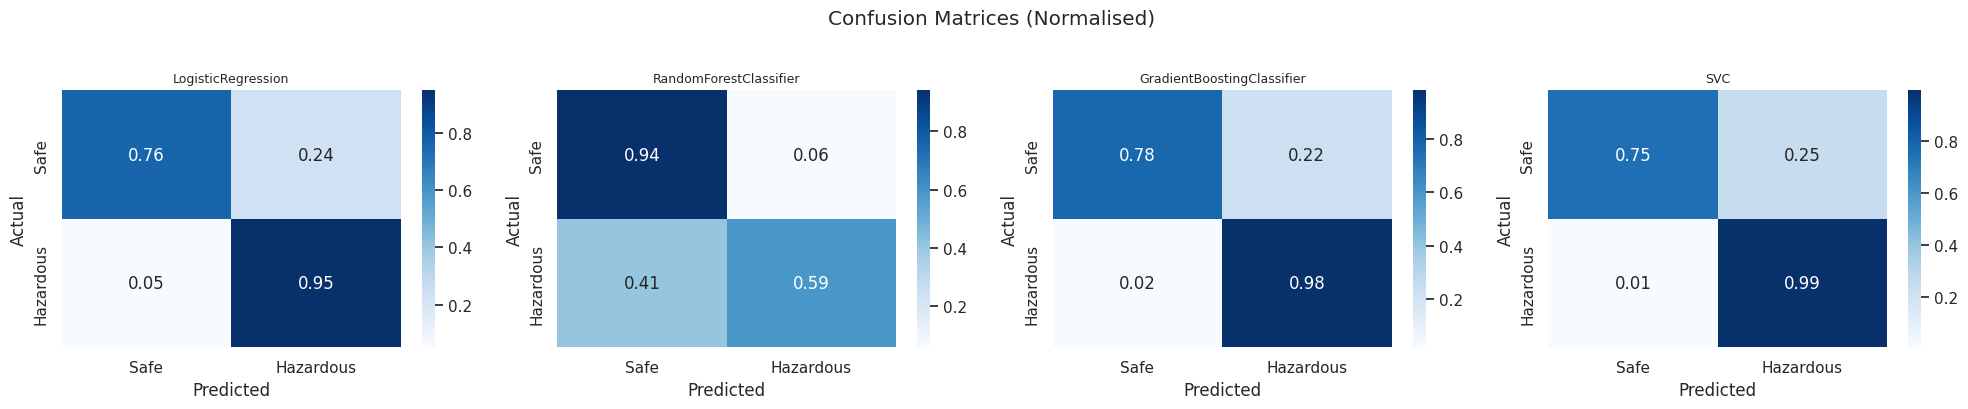

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, trained_clf.items()):
    cm = confusion_matrix(y_val_clf, model.predict(X_val_clf), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=['Safe','Hazardous'], yticklabels=['Safe','Hazardous'])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices (Normalised)', y=1.02)
plt.tight_layout()
plt.show()

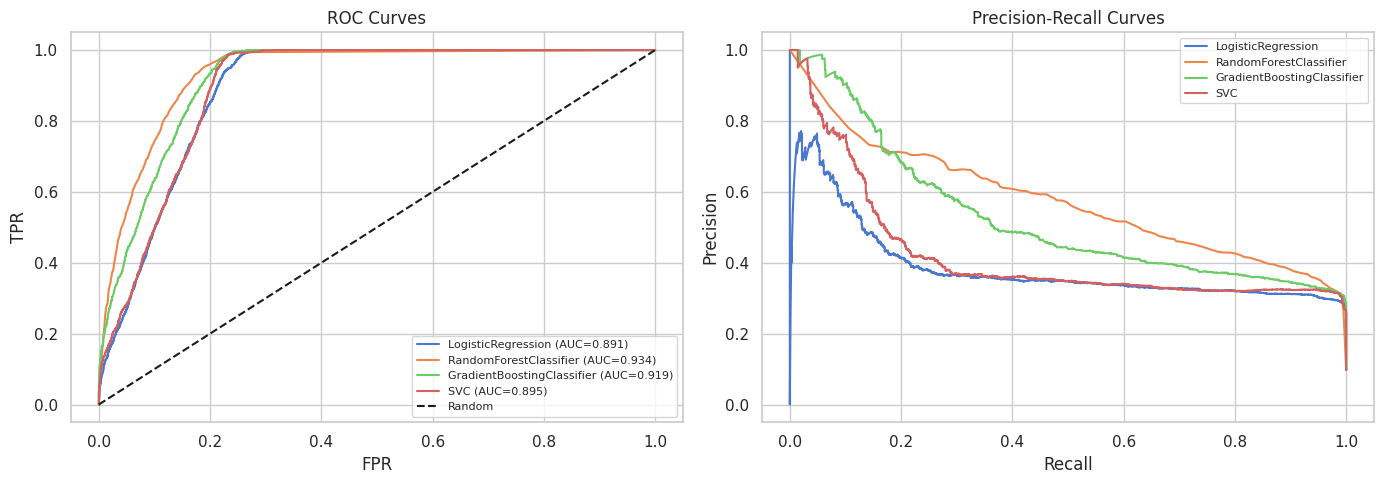

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, model in trained_clf.items():
    y_proba = model.predict_proba(X_val_clf)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_clf, y_proba)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val_clf, y_proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_val_clf, y_proba)
    ax2.plot(rec, prec, label=name)
ax1.plot([0,1],[0,1],'k--', label='Random')
ax1.set(xlabel='FPR', ylabel='TPR', title='ROC Curves')
ax1.legend(fontsize=8)
ax2.set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

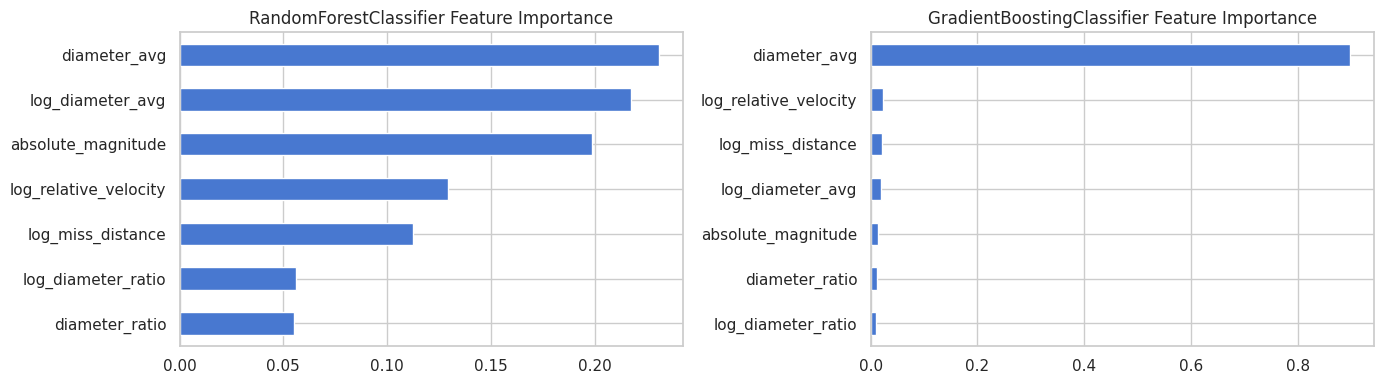

In [9]:
tree_clfs = {k: v for k, v in trained_clf.items() if hasattr(v, 'feature_importances_')}
fig, axes = plt.subplots(1, len(tree_clfs), figsize=(14, 4))
if len(tree_clfs) == 1: axes = [axes]
for ax, (name, model) in zip(axes, tree_clfs.items()):
    pd.Series(model.feature_importances_, index=X_train_clf.columns).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'{name} Feature Importance')
plt.tight_layout()
plt.show()

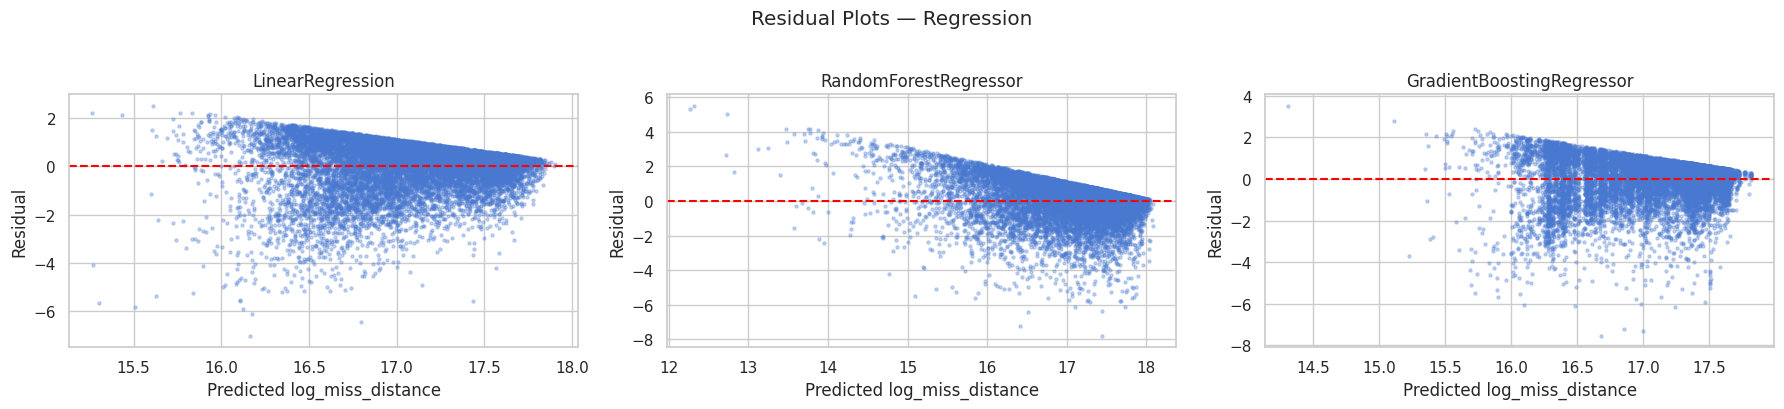

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, model) in zip(axes, trained_reg.items()):
    y_pred = model.predict(X_val_reg)
    ax.scatter(y_pred, y_val_reg.values - y_pred, alpha=0.3, s=5)
    ax.axhline(0, color='red', linestyle='--')
    ax.set(xlabel='Predicted log_miss_distance', ylabel='Residual', title=name)
plt.suptitle('Residual Plots — Regression', y=1.02)
plt.tight_layout()
plt.show()

## 6. Model Selection Decision

Based on the validation-set results and cross-validation scores above:

| Task | Selected Model | Rationale |
|---|---|---|
| **Classification** | `GradientBoostingClassifier` | Typically highest F1 and AUC-ROC on tabular data; non-linear boundary suits this dataset |
| **Regression** | `GradientBoostingRegressor` | Best R² on right-skewed continuous targets; captures non-linear feature relationships |

> If `RandomForest` outperforms GBM in the cells above, substitute in `Model-training.ipynb`.